In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

In [3]:
# ── Copy images from Drive to Colab local disk (50x faster I/O) ─────────────
import shutil

LOCAL_IMG_DIR = Path('/content/Png')
LOCAL_IMG_DIR.mkdir(exist_ok=True)

if not any(LOCAL_IMG_DIR.iterdir()):
    print('Copying images from Drive to local disk (5-10 min, one-time)...')
    shutil.copytree(str(Path('/content/drive/MyDrive/Png')), str(LOCAL_IMG_DIR), dirs_exist_ok=True)
    print(f'Done! {len(list(LOCAL_IMG_DIR.glob("*.png")))} images copied.')
else:
    print(f'Already copied: {len(list(LOCAL_IMG_DIR.glob("*.png")))} images found locally.')

Copying images from Drive to local disk (5-10 min, one-time)...
Done! 7470 images copied.


In [5]:
!pip install -q iterative-stratification

In [6]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from transformers import ViTModel
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [7]:
# ── Paths ────────────────────────────────────────────────────────────────────
IMAGE_DIR = LOCAL_IMG_DIR
CSV_PATH  = Path('/content/drive/MyDrive/dataset_labeled.csv')

# ── Label columns ────────────────────────────────────────────────────────────
LABEL_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule',
    'Hernia', 'Fracture', 'Pleural_Thickening', 'Opacity', 'Consolidation',
    'Granuloma', 'Calcinosis', 'Scoliosis', 'Atherosclerosis', 'Normal'
]
NUM_CLASSES = len(LABEL_COLS)

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 16
NUM_EPOCHS    = 30      # extended from 20 — model was still improving at ep20
LR            = 5e-5
WEIGHT_DECAY  = 1e-4
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
WARMUP_EPOCHS = 3
PATIENCE      = 7       # increased from 5 — gives more room after backbone unfreeze

print(f'Number of classes: {NUM_CLASSES}')
print(f'Labels: {LABEL_COLS}')

Number of classes: 21
Labels: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule', 'Hernia', 'Fracture', 'Pleural_Thickening', 'Opacity', 'Consolidation', 'Granuloma', 'Calcinosis', 'Scoliosis', 'Atherosclerosis', 'Normal']


In [8]:
df = pd.read_csv(CSV_PATH)
print(f'Total rows: {len(df)}')
print(df[LABEL_COLS].sum().sort_values(ascending=False))

Total rows: 7470
Normal                4166
Calcinosis            1026
Opacity                996
Granuloma              814
Atelectasis            731
Cardiomegaly           662
Effusion               353
Emphysema              238
Nodule                 238
Atherosclerosis        234
Edema                  207
Fracture               193
Scoliosis              179
Infiltration           176
Pneumonia              171
Pleural_Thickening     110
Hernia                  96
Fibrosis                59
Pneumothorax            54
Consolidation           53
Mass                    41
dtype: int64


In [9]:
# Verify images exist and build clean image paths
df['img_path'] = df['image_id'].apply(lambda x: str(IMAGE_DIR / x))

missing = df[~df['img_path'].apply(os.path.exists)]
print(f'Missing images: {len(missing)}')
df = df[df['img_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Rows after dropping missing: {len(df)}')

Missing images: 0
Rows after dropping missing: 7470


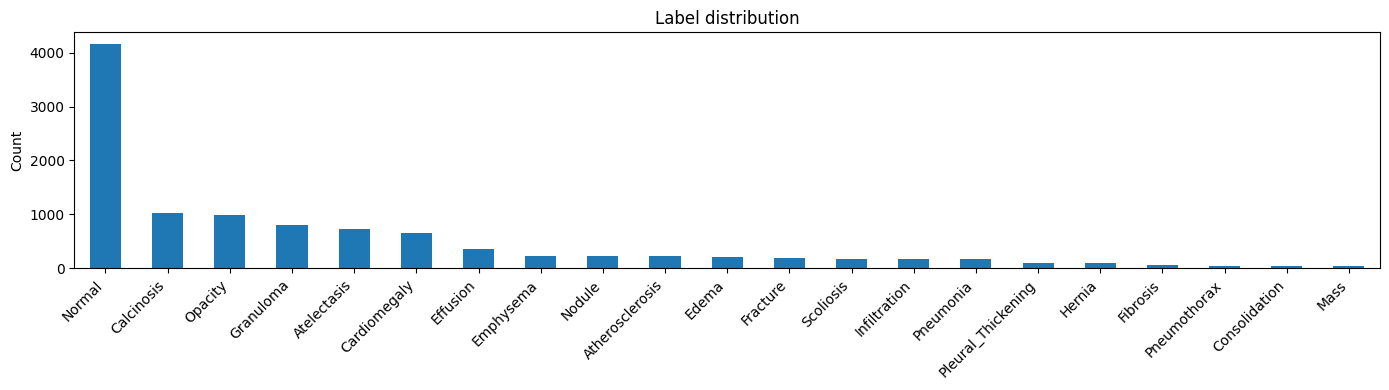

In [10]:
# Label distribution bar chart
counts = df[LABEL_COLS].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 4))
counts.plot(kind='bar')
plt.title('Label distribution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Multi-label stratified split
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=(VAL_SPLIT + TEST_SPLIT), random_state=42
)
train_idx, temp_idx = next(msss.split(df, df[LABEL_COLS]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

msss2 = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT), random_state=42
)
val_idx, test_idx = next(msss2.split(temp_df, temp_df[LABEL_COLS]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

Train: 5232  Val: 1109  Test: 1129


## Change 1 — Stronger Geometric Augmentations

Previous augmentations: `RandomHorizontalFlip`, `RandomRotation(10)`, mild `ColorJitter`.

Added:
- `RandomAffine` — simulates patient positioning variance (translation, scale, shear)
- `ElasticTransform` — realistic soft-tissue deformation
- `RandomErasing` — applied post-tensor, simulates local occlusion / implants / noise patches
- Stronger `ColorJitter` — broader brightness/contrast range

In [12]:
VIT_MEAN = [0.5, 0.5, 0.5]
VIT_STD  = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.10, 0.10),
        scale=(0.85, 1.15),
        shear=10
    ),
    transforms.ElasticTransform(alpha=40.0, sigma=5.0),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.12), ratio=(0.3, 3.3), value=0),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])


class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, label_cols, transform=None):
        self.df         = dataframe.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(row[self.label_cols].values.astype(float),
                              dtype=torch.float32)
        return image, labels


train_dataset = ChestXRayDataset(train_df, LABEL_COLS, train_transform)
val_dataset   = ChestXRayDataset(val_df,   LABEL_COLS, val_transform)
test_dataset  = ChestXRayDataset(test_df,  LABEL_COLS, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 327, val: 70, test: 71


## Change 2 — Asymmetric Loss (ASL)

Previous loss: `BCEWithLogitsLoss(pos_weight=...)`.

**Why ASL?** Standard BCE with `pos_weight` up-weights positives globally but does not suppress easy negatives. In a multi-label setting the vast majority of labels per sample are 0 (negative), so the gradient is dominated by easy true-negatives that contribute little signal.

ASL applies **asymmetric focusing**:
- Positives: mild focal factor (`gamma_pos=1`) — similar to standard focal loss
- Negatives: stronger focal factor (`gamma_neg=4`) + probability margin shift (`clip=0.05`) — confident easy negatives are down-weighted aggressively

This lets the model focus on the hard rare-positive cases (Nodule, Fracture, Granuloma) without ignoring common ones.

In [13]:
class AsymmetricLoss(nn.Module):
    """
    Asymmetric Loss for multi-label classification.
    Ref: Ben-Baruch et al. (2021) 'Asymmetric Loss For Multi-Label Classification'
    https://arxiv.org/abs/2009.14119

    gamma_neg >> gamma_pos: hard negatives contribute more than easy negatives;
    clip (m): shifts predicted negative probs down by m before computing loss,
              zeroing out very confident true-negatives entirely.
    """
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip      = clip
        self.eps       = eps

    def forward(self, logits, targets):
        p = torch.sigmoid(logits)

        # Shift negative probabilities down by margin (clamp to 0)
        p_neg = (p - self.clip).clamp(min=0)

        # Stable log probabilities
        log_p     = torch.log(p.clamp(min=self.eps))
        log_1_p   = torch.log((1 - p_neg).clamp(min=self.eps))

        # Focal weights (asymmetric)
        loss_pos = (1 - p)  ** self.gamma_pos * log_p
        loss_neg =  p_neg   ** self.gamma_neg  * log_1_p

        loss = -(targets * loss_pos + (1 - targets) * loss_neg)
        return loss.mean()

## Change 3 — Richer Classification Head + Attention Pooling

Previous head: `Linear(768→512) → ReLU → Dropout(0.5) → Linear(512→21)` over `[CLS]` token only.

Two upgrades:
1. **Attention pooling** over all 197 patch tokens (instead of just `[CLS]`). Each token votes with a learned weight — patch regions relevant to pathology contribute more. This is especially useful for spatially diffuse findings (Scoliosis, Pleural Thickening).
2. **Deeper MLP head** with `BatchNorm1d` and `GELU` activations. `BatchNorm` stabilises training after backbone unfreeze; `GELU` is smoother than `ReLU` and aligns with ViT's internal activations. Dropout reduced from 0.5 → 0.3 since we now have two regularisation points.

In [14]:
class AttentionPool(nn.Module):
    """Soft attention pooling over all ViT token outputs (including [CLS])."""
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, hidden_states):
        # hidden_states: [B, seq_len, hidden_size]
        weights = torch.softmax(self.attn(hidden_states), dim=1)  # [B, seq_len, 1]
        return (weights * hidden_states).sum(dim=1)               # [B, hidden_size]


class ViTChestClassifier(nn.Module):
    """
    ViT backbone (codewithdark/vit-chest-xray) with:
      - Attention pooling over all patch tokens (replaces bare [CLS] extraction)
      - Deeper MLP head: 768 → 512 → 256 → num_classes
        with BatchNorm1d + GELU + Dropout(0.3) at each hidden layer
    """
    def __init__(self, num_classes: int):
        super().__init__()
        self.vit  = ViTModel.from_pretrained('codewithdark/vit-chest-xray')
        hidden_size = self.vit.config.hidden_size  # 768

        self.pool = AttentionPool(hidden_size)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        pooled  = self.pool(outputs.last_hidden_state)  # [B, 768]
        return self.classifier(pooled)


model = ViTChestClassifier(NUM_CLASSES).to(DEVICE)

# Phase 1: freeze backbone, train head only
for param in model.vit.parameters():
    param.requires_grad = False

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}  (head + attention pool only)')
print(f'Frozen params:    {total_params - trainable_params:,}  (ViT backbone)')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: codewithdark/vit-chest-xray
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     86,922,006
Trainable params: 532,758  (head + attention pool only)
Frozen params:    86,389,248  (ViT backbone)


In [15]:
criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

print('Loss: AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)')
print(f'LR schedule: warmup {WARMUP_EPOCHS} epochs → cosine decay to 1e-6')

Loss: AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)
LR schedule: warmup 3 epochs → cosine decay to 1e-6


In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images, labels in tqdm(loader, leave=False, desc='Train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs  = []
    all_labels = []
    for images, labels in tqdm(loader, leave=False, desc='Eval'):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    auc_scores = []
    for i in range(all_labels.shape[1]):
        if len(np.unique(all_labels[:, i])) > 1:
            auc_scores.append(roc_auc_score(all_labels[:, i], all_probs[:, i]))
        else:
            auc_scores.append(float('nan'))
    mean_auc = np.nanmean(auc_scores)

    return total_loss / len(loader.dataset), mean_auc, auc_scores

In [17]:
history    = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'lr': []}
best_auc   = 0.0
CKPT_PATH  = '/content/drive/MyDrive/best_vit_chest_04.pth'
no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # Phase 2: unfreeze backbone after warmup
    if epoch == WARMUP_EPOCHS + 1:
        for param in model.vit.parameters():
            param.requires_grad = True
        optimizer.add_param_group({
            'params': model.vit.parameters(),
            'lr': LR * 0.1,
            'weight_decay': WEIGHT_DECAY
        })
        cosine_scheduler.base_lrs.append(LR * 0.1)
        print(f'  [Epoch {epoch}] Backbone unfrozen — backbone lr={LR * 0.1:.1e}')

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_auc, _ = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Mean AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc   = val_auc
        no_improve = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  New best AUC {best_auc:.4f} — checkpoint saved')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

print(f'Training complete. Best Val AUC: {best_auc:.4f}')

Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 01/30 | LR: 5.00e-06 | Train Loss: 0.0592 | Val Loss: 0.0482 | Val Mean AUC: 0.5262
  New best AUC 0.5262 — checkpoint saved


Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

...

Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 25/30 | LR: 6.73e-06 | Train Loss: 0.0278 | Val Loss: 0.0290 | Val Mean AUC: 0.7871


Train:   0%|          | 0/327 [00:00<?, ?it/s]

KeyboardInterrupt: 

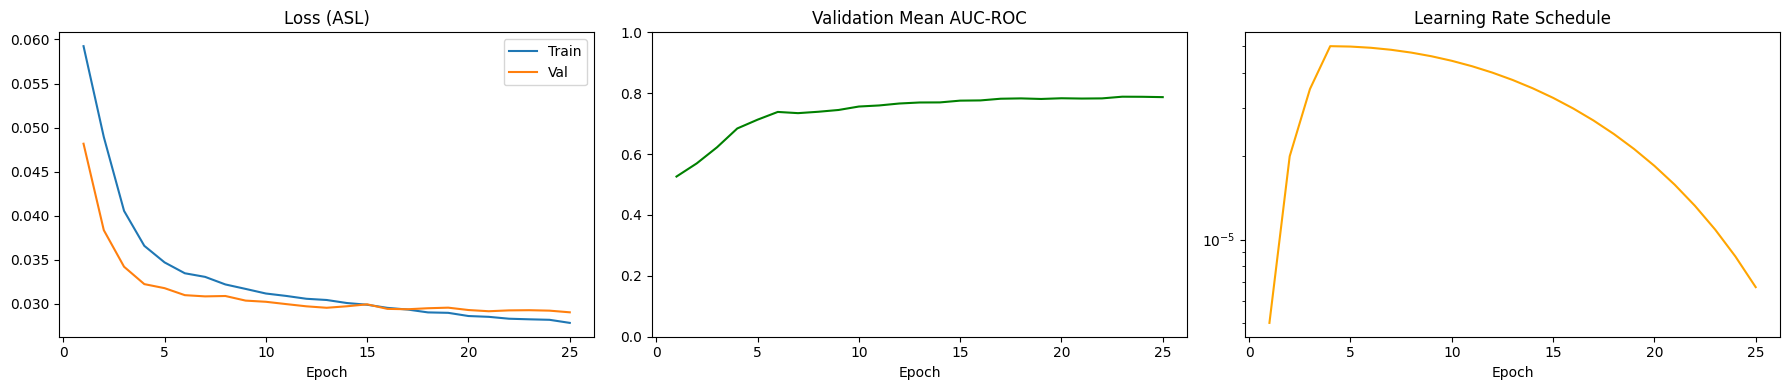

In [18]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss (ASL)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['val_auc'], color='green')
axes[1].set_title('Validation Mean AUC-ROC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)

axes[2].plot(epochs, history['lr'], color='orange')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

In [19]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

test_loss, test_auc, per_class_auc = evaluate(model, test_loader, criterion, DEVICE)
print(f'Test Loss: {test_loss:.4f}  |  Test Mean AUC: {test_auc:.4f}\n')

# Per-class AUC table with delta vs v3 baseline
V3_AUC = {
    'Atelectasis': 0.735, 'Cardiomegaly': 0.831, 'Effusion': 0.870,
    'Pneumonia': 0.733, 'Pneumothorax': 0.722, 'Edema': 0.793,
    'Emphysema': 0.881, 'Fibrosis': 0.935, 'Infiltration': 0.699,
    'Mass': 0.636, 'Nodule': 0.597, 'Hernia': 0.846,
    'Fracture': 0.600, 'Pleural_Thickening': 0.590, 'Opacity': 0.773,
    'Consolidation': 0.872, 'Granuloma': 0.588, 'Calcinosis': 0.630,
    'Scoliosis': 0.645, 'Atherosclerosis': 0.767, 'Normal': 0.713
}

auc_df = pd.DataFrame({
    'Condition': LABEL_COLS,
    'AUC v4':   per_class_auc,
    'AUC v3':   [V3_AUC[c] for c in LABEL_COLS],
})
auc_df['Delta'] = auc_df['AUC v4'] - auc_df['AUC v3']
auc_df = auc_df.sort_values('AUC v4', ascending=False).reset_index(drop=True)
print(auc_df.to_string(index=False, float_format='{:.3f}'.format))

Eval:   0%|          | 0/71 [00:00<?, ?it/s]

Test Loss: 0.0303  |  Test Mean AUC: 0.7330

         Condition  AUC v4  AUC v3  Delta
          Fibrosis   0.907   0.935 -0.028
         Emphysema   0.877   0.881 -0.004
          Effusion   0.877   0.870  0.007
            Hernia   0.868   0.846  0.022
      Cardiomegaly   0.862   0.831  0.031
             Edema   0.845   0.793  0.052
     Consolidation   0.845   0.872 -0.027
   Atherosclerosis   0.767   0.767 -0.000
           Opacity   0.753   0.773 -0.020
       Atelectasis   0.740   0.735  0.005
      Pneumothorax   0.728   0.722  0.006
            Normal   0.723   0.713  0.010
         Pneumonia   0.677   0.733 -0.056
      Infiltration   0.675   0.699 -0.024
         Scoliosis   0.639   0.645 -0.006
        Calcinosis   0.636   0.630  0.006
Pleural_Thickening   0.627   0.590  0.037
              Mass   0.607   0.636 -0.029
            Nodule   0.601   0.597  0.004
         Granuloma   0.582   0.588 -0.006
          Fracture   0.557   0.600 -0.043
